# Exploratory Data Analysis on Retail Sales Data

## OASIS Infobyte – Data Analytics Level 1 – Task 1

**Objective:**  
To perform Exploratory Data Analysis (EDA) on retail sales data and identify
sales patterns, customer behaviour, product/category performance, and
actionable business insights.

**Tools Used:** Python, Pandas, Matplotlib, Seaborn, Jupyter Notebook

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("data/customer_shopping_data.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
df.head()


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 99457
Number of columns: 10


In [6]:
print("Column names:")
print(df.columns.tolist())

Column names:
['invoice_no', 'customer_id', 'gender', 'age', 'category', 'quantity', 'price', 'payment_method', 'invoice_date', 'shopping_mall']


In [7]:
df.dtypes

invoice_no            str
customer_id           str
gender                str
age                 int64
category              str
quantity            int64
price             float64
payment_method        str
invoice_date          str
shopping_mall         str
dtype: object

In [8]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64


In [9]:
numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(numerical_columns.tolist())

Numerical columns:
['age', 'quantity', 'price']


In [10]:
print("MEAN")
print(df[numerical_columns].mean())

MEAN
age          43.427089
quantity      3.003429
price       689.256321
dtype: float64


In [11]:
print("MEDIAN")
print(df[numerical_columns].median())

MEDIAN
age          43.0
quantity      3.0
price       203.3
dtype: float64


In [12]:
print("MODE")
print(df[numerical_columns].mode().iloc[0])

MODE
age          37.00
quantity      3.00
price       600.16
Name: 0, dtype: float64


In [13]:
print("STANDARD DEVIATION")
print(df[numerical_columns].std())

STANDARD DEVIATION
age          14.990054
quantity      1.413025
price       941.184567
dtype: float64


In [14]:
df[numerical_columns].describe()

,age,quantity,price
count,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,689.256321
std,14.990054,1.413025,941.184567
min,18.000000,1.000000,5.230000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,69.000000,5.000000,5250.000000


In [15]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'], dayfirst=True)

print("Invoice date converted successfully!")
print(df['invoice_date'].dtype)

Invoice date converted successfully!
datetime64[us]


In [16]:
df['revenue'] = df['quantity'] * df['price']

df[['quantity', 'price', 'revenue']].head()

,quantity,price,revenue
0,5,1500.40,7502.00
1,3,1800.51,5401.53
2,1,300.08,300.08
3,5,3000.85,15004.25
4,4,60.60,242.40


In [17]:
df['month'] = df['invoice_date'].dt.to_period('M')

monthly_sales = df.groupby('month')['revenue'].sum()

print("Monthly sales:")
print(monthly_sales)

Monthly sales:
month
2021-01     9641614.62
2021-02     8772315.22
2021-03     9455359.38
2021-04     9389541.54
2021-05     9771756.97
2021-06     9286271.35
2021-07    10311119.68
2021-08     9630655.70
2021-09     9188165.62
2021-10    10263015.06
2021-11     9265555.29
2021-12     9585200.16
2022-01     9764311.14
2022-02     8344111.92
2022-03     9986685.16
2022-04     9326144.44
2022-05     9947574.13
2022-06     9647503.95
2022-07    10067602.95
2022-08     9651705.59
2022-09     9607629.29
2022-10    10282075.37
2022-11     8941584.66
2022-12     9869885.48
2023-01     9485599.83
2023-02     9508662.96
2023-03     2514146.79
Freq: M, Name: revenue, dtype: float64


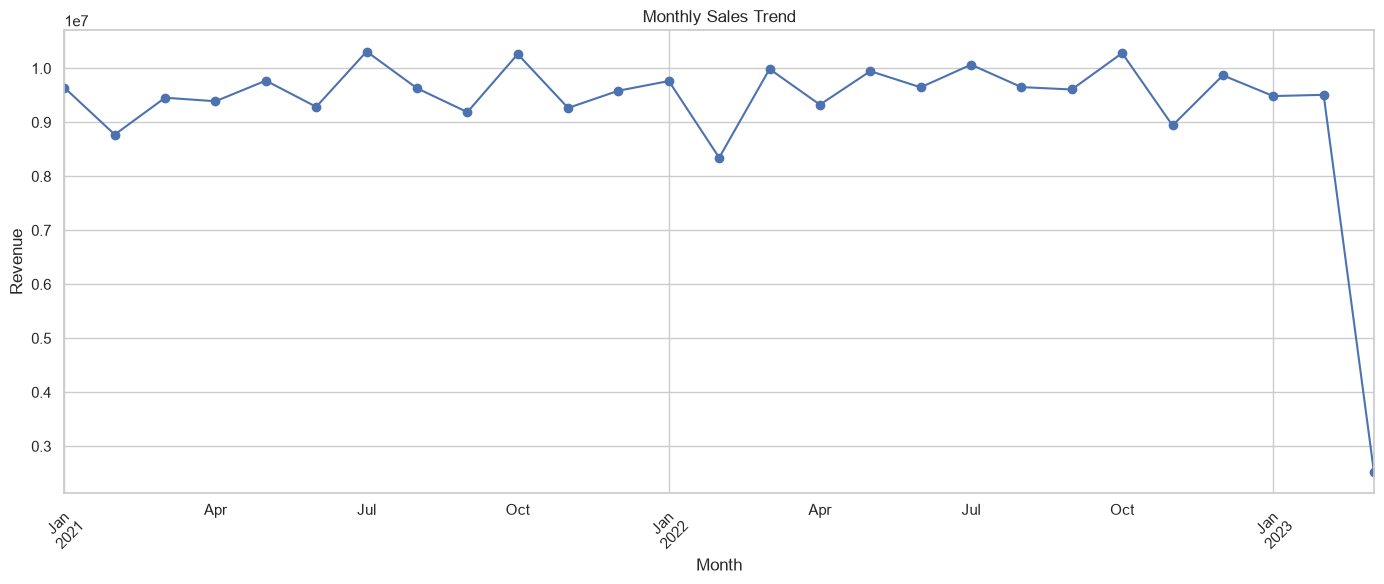

In [18]:
plt.figure(figsize=(14, 6))

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation – Monthly Sales Trend

The monthly sales trend shows how revenue changes over time. 
The chart helps identify months with higher and lower sales and 
possible seasonal patterns. These patterns can help businesses 
plan inventory and marketing activities.

In [19]:
df['quarter'] = df['invoice_date'].dt.to_period('Q')

quarterly_sales = df.groupby('quarter')['revenue'].sum()

print("Quarterly sales:")
print(quarterly_sales)

Quarterly sales:
quarter
2021Q1    27869289.22
2021Q2    28447569.86
2021Q3    29129941.00
2021Q4    29113770.51
2022Q1    28095108.22
2022Q2    28921222.52
2022Q3    29326937.83
2022Q4    29093545.51
2023Q1    21508409.58
Freq: Q-DEC, Name: revenue, dtype: float64


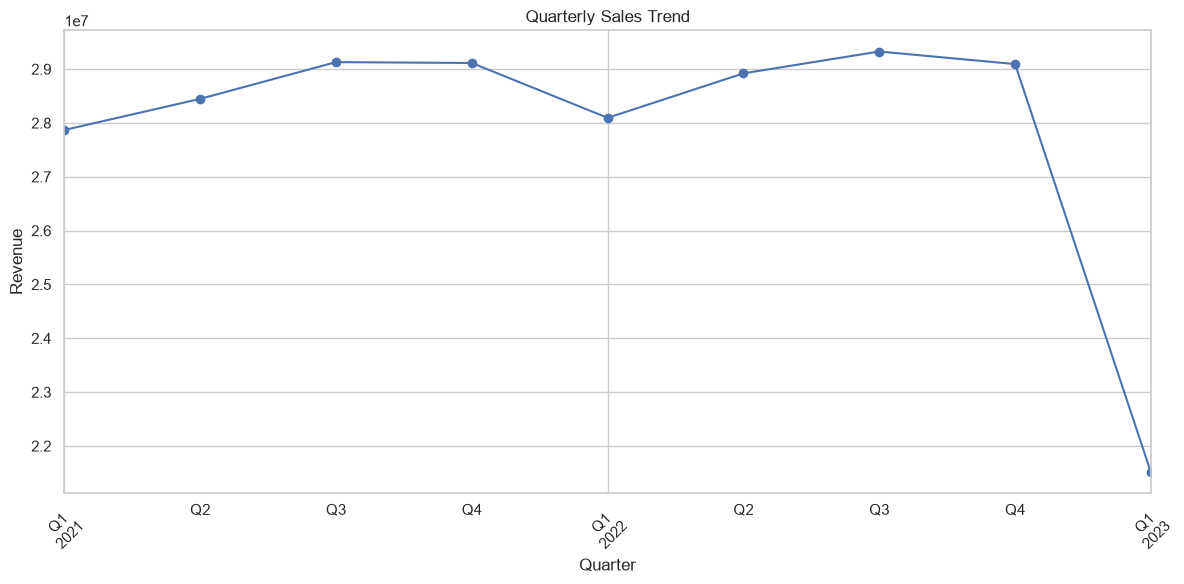

In [20]:
plt.figure(figsize=(12, 6))

quarterly_sales.plot(kind='line', marker='o')

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation – Quarterly Sales Trend

The quarterly sales trend provides a broader view of the company's
sales performance. It helps identify strong and weak quarters and
can support business planning, inventory management, and promotional
decisions.

In [21]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]

labels = [
    'Under 18',
    '18-25',
    '26-35',
    '36-45',
    '46-55',
    '56-65',
    '65+'
]

df['age_group'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels
)

print(df['age_group'].value_counts().sort_index())

age_group
Under 18     1844
18-25       13515
26-35       19059
36-45       19436
46-55       19016
56-65       19016
65+          7571
Name: count, dtype: int64


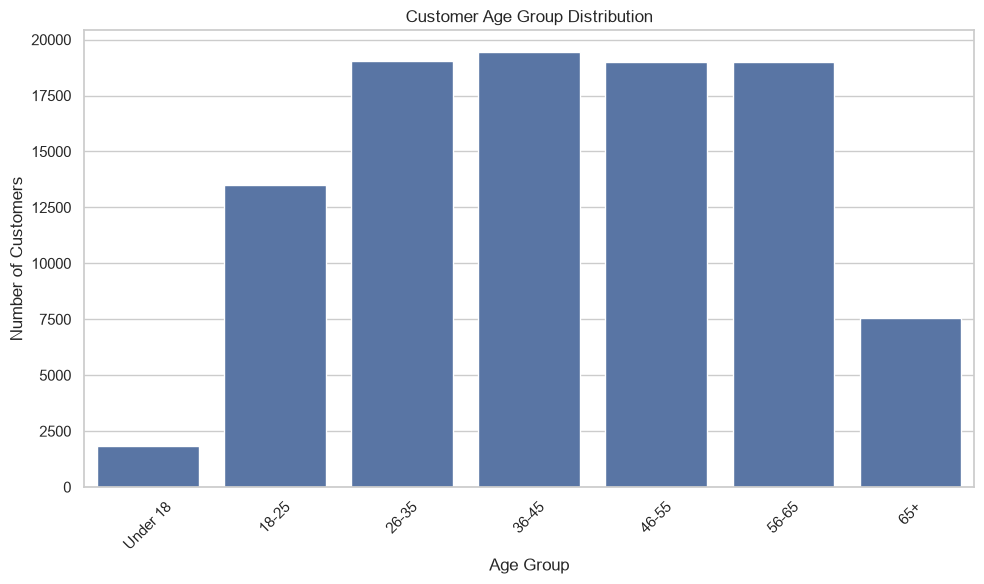

In [22]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='age_group',
    order=labels
)

plt.title('Customer Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation – Customer Age Group Distribution

The age-group distribution shows which customer age groups contribute
the largest number of transactions. This information can help the
business design age-specific marketing campaigns, offers, and product
recommendations.

In [23]:
gender_counts = df['gender'].value_counts()

print("Gender breakdown:")
print(gender_counts)

Gender breakdown:
gender
Female    59482
Male      39975
Name: count, dtype: int64


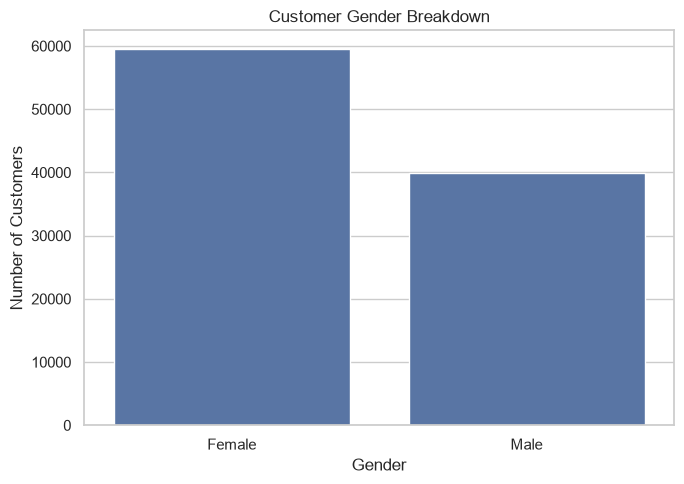

In [24]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='gender'
)

plt.title('Customer Gender Breakdown')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

### Observation – Gender Breakdown

The gender distribution shows the composition of the customer base.
This information can help the business understand its customers and
develop more targeted marketing strategies.

In [25]:
category_quantity = (
    df.groupby('category')['quantity']
    .sum()
    .sort_values(ascending=False)
)

print("Quantity sold by category:")
print(category_quantity)

Quantity sold by category:
category
Clothing           103558
Cosmetics           45465
Food & Beverage     44277
Toys                30321
Shoes               30217
Technology          15021
Books               14982
Souvenir            14871
Name: quantity, dtype: int64


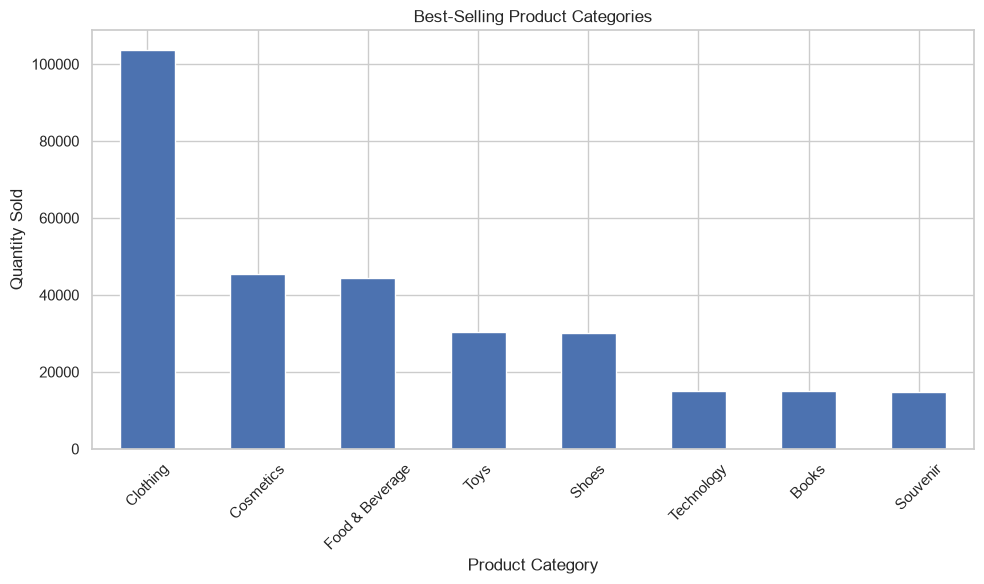

In [26]:
plt.figure(figsize=(10, 6))

category_quantity.plot(kind='bar')

plt.title('Best-Selling Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation – Best-Selling Product Categories

The chart compares the total quantity sold across product categories.
The categories with the highest sales volume can be prioritized for
inventory planning, promotions, and marketing campaigns.

In [27]:
category_revenue = (
    df.groupby('category')['revenue']
    .sum()
    .sort_values(ascending=False)
)

print("Revenue by category:")
print(category_revenue)

Revenue by category:
category
Clothing           1.139968e+08
Shoes              6.655345e+07
Technology         5.786235e+07
Cosmetics          6.792863e+06
Toys               3.980426e+06
Food & Beverage    8.495351e+05
Books              8.345529e+05
Souvenir           6.358247e+05
Name: revenue, dtype: float64


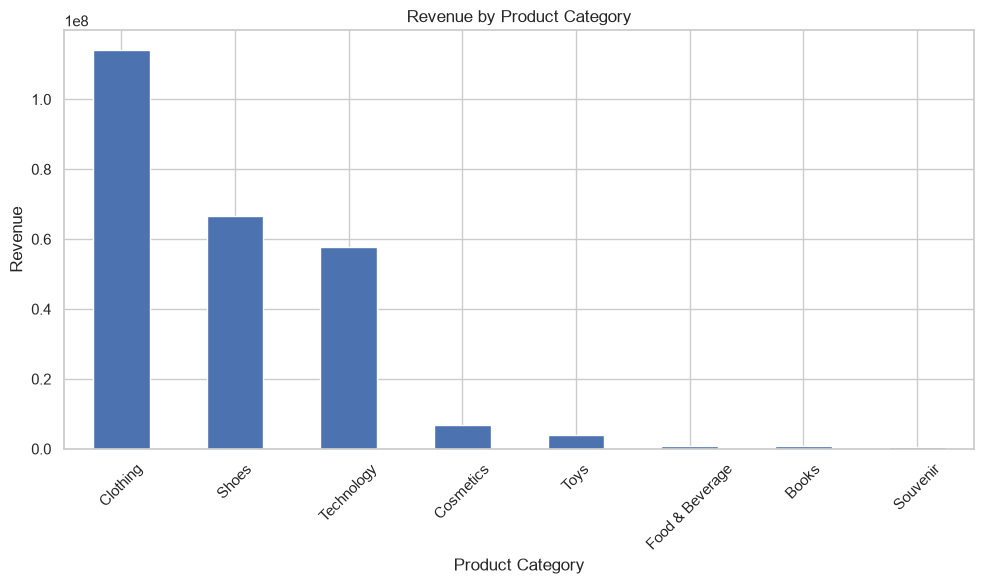

In [28]:
plt.figure(figsize=(10, 6))

category_revenue.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation – Revenue by Product Category

The revenue comparison shows which product categories contribute the
most to total sales. High-revenue categories are important for business
growth, while lower-revenue categories may require improved pricing,
promotion, or product strategies.

In [29]:
correlation = df[numerical_columns.tolist() + ['revenue']].corr()

print(correlation)

               age  quantity     price   revenue
age       1.000000  0.000667  0.001694  0.002731
quantity  0.000667  1.000000  0.344880  0.461173
price     0.001694  0.344880  1.000000  0.962372
revenue   0.002731  0.461173  0.962372  1.000000


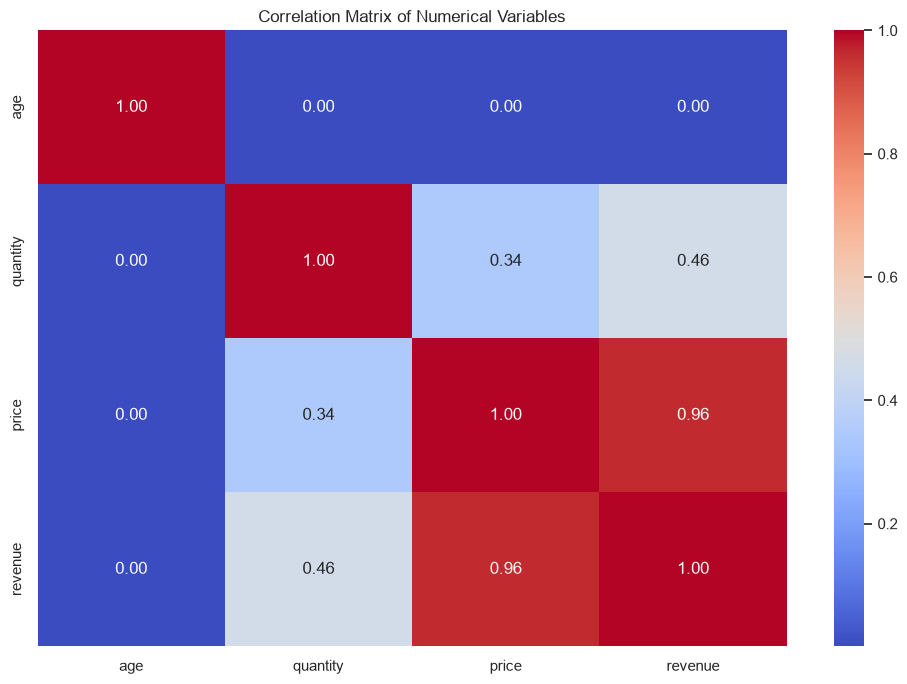

In [30]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

### Observation – Correlation Heatmap

The correlation heatmap shows the relationships between numerical
variables in the retail dataset. A positive correlation means that
two variables tend to increase together, while a negative correlation
means that they tend to move in opposite directions.

Revenue has a strong relationship with quantity and price because
revenue is calculated using quantity multiplied by price.

In [31]:
payment_revenue = (
    df.groupby('payment_method')['revenue']
    .sum()
    .sort_values(ascending=False)
)

print("Revenue by payment method:")
print(payment_revenue)

Revenue by payment method:
payment_method
Cash           1.128322e+08
Credit Card    8.807712e+07
Debit Card     5.059643e+07
Name: revenue, dtype: float64


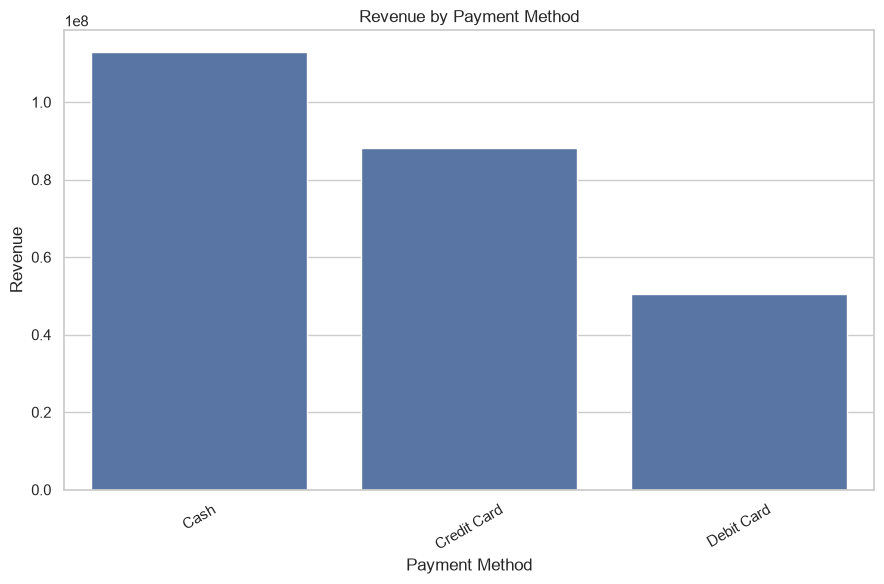

In [32]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=payment_revenue.index,
    y=payment_revenue.values
)

plt.title('Revenue by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Revenue')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Observation – Revenue by Payment Method

The chart shows how total revenue is distributed across different
payment methods. Differences in revenue can provide insight into
customer payment preferences and help businesses improve the
checkout experience by supporting commonly used payment methods.

In [33]:
mall_revenue = (
    df.groupby('shopping_mall')['revenue']
    .sum()
    .sort_values(ascending=False)
)

print("Revenue by shopping mall:")
print(mall_revenue)

Revenue by shopping mall:
shopping_mall
Mall of Istanbul     50872481.68
Kanyon               50554231.10
Metrocity            37302787.33
Metropol AVM         25379913.19
Istinye Park         24618827.68
Zorlu Center         12901053.82
Cevahir AVM          12645138.20
Viaport Outlet       12521339.72
Emaar Square Mall    12406100.29
Forum Istanbul       12303921.24
Name: revenue, dtype: float64


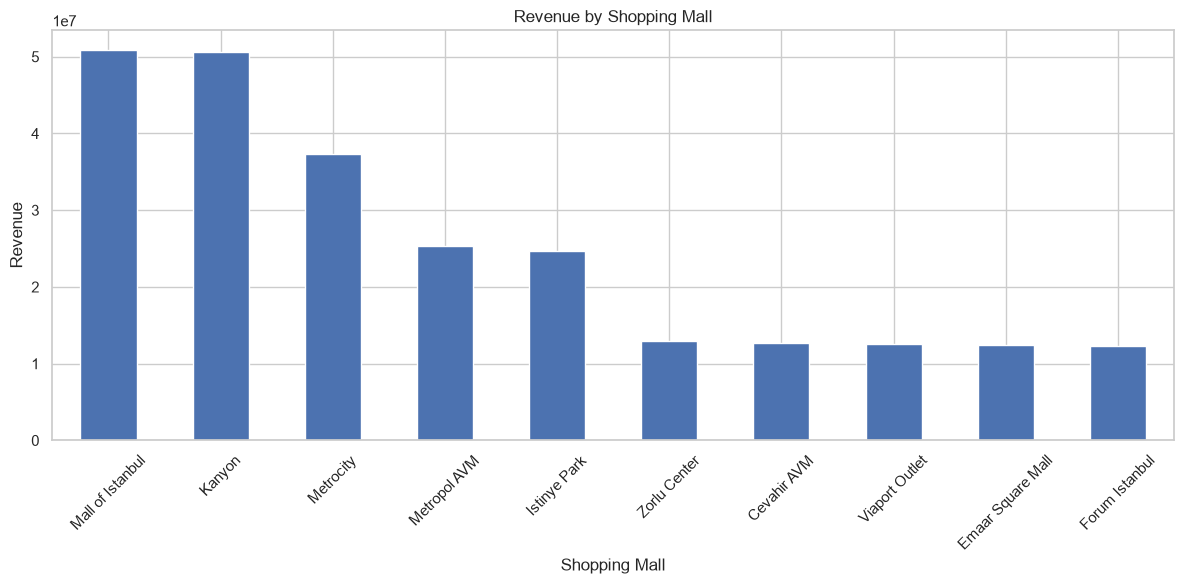

In [34]:
plt.figure(figsize=(12, 6))

mall_revenue.plot(kind='bar')

plt.title('Revenue by Shopping Mall')
plt.xlabel('Shopping Mall')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation – Revenue by Shopping Mall

Revenue varies across shopping malls. High-performing malls may provide
useful information about customer demand and purchasing behaviour.
Businesses can use this information when planning inventory, promotions,
and location-based strategies.

In [35]:
print("KEY FINDINGS")
print("-" * 50)

print("Highest revenue category:", category_revenue.idxmax())
print("Highest quantity-selling category:", category_quantity.idxmax())
print("Highest revenue shopping mall:", mall_revenue.idxmax())
print("Highest revenue payment method:", payment_revenue.idxmax())

print("\nTotal Revenue:", df['revenue'].sum())
print("Total Quantity Sold:", df['quantity'].sum())
print("Average Transaction Revenue:", df['revenue'].mean())

KEY FINDINGS
--------------------------------------------------
Highest revenue category: Clothing
Highest quantity-selling category: Clothing
Highest revenue shopping mall: Mall of Istanbul
Highest revenue payment method: Cash

Total Revenue: 251505794.25
Total Quantity Sold: 298712
Average Transaction Revenue: 2528.7892682264696


# Key Findings

The exploratory data analysis produced several important findings:

1. **Sales Performance:** Monthly and quarterly analysis shows how
   revenue changes over time and helps identify periods of stronger
   and weaker sales.

2. **Customer Demographics:** The age-group and gender analysis provides
   an understanding of the customer base and purchasing behaviour.

3. **Product Categories:** Some product categories generate higher
   quantities sold and higher revenue than others.

4. **Payment Methods:** Revenue varies across payment methods, providing
   insight into customer checkout preferences.

5. **Shopping Mall Performance:** Revenue differs across shopping malls,
   showing that location can influence sales performance.

6. **Relationships Between Variables:** The correlation heatmap helps
   identify relationships between numerical variables such as age,
   quantity, price, and revenue.

# Business Recommendations

Based on the EDA findings, the following actions are recommended:

### 1. Prioritize high-performing categories
Maintain sufficient inventory for categories with high sales volume and
revenue to avoid stock shortages.

### 2. Use customer demographics for targeted marketing
Use age-group and gender insights to design targeted offers,
advertisements, and product recommendations.

### 3. Plan inventory using sales trends
Use monthly and quarterly sales patterns to prepare inventory before
periods of increased demand.

### 4. Improve performance of lower-performing locations
Study successful shopping malls and apply their effective sales and
marketing strategies to lower-performing locations.

### 5. Support popular payment methods
Ensure that commonly used payment methods remain available and easy
to use during checkout.

### 6. Use data-driven promotional strategies
Combine category, customer, location, and time-based insights to
create more effective promotional campaigns.

# Conclusion

This Exploratory Data Analysis of retail sales data helped identify
important patterns in sales performance, customer demographics,
product categories, payment methods, and shopping-mall performance.

The analysis used Python, Pandas, Matplotlib, and Seaborn to transform
the raw retail dataset into meaningful visualizations and insights.

The findings can help a retail business make better decisions about
inventory management, customer targeting, marketing campaigns,
payment options, and location-based strategies.

Overall, EDA provides a strong foundation for making data-driven
business decisions and improving retail sales performance.